### Set Up

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from functools import reduce
import os
import sys

In [2]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

In [3]:
scenarios_path = Path().resolve() / "../../scenarios_inputs" / "cheung_variants" 
annotated_output_path = Path().resolve() / "../../annotated_outputs" / "cheung_variants"
plots_path = Path().resolve() / "../../analysis" / "cheung_variants" / "cheung_visualizations"
print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")



scenarios_path: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../scenarios_inputs/cheung_variants
annotated_output_path: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants


In [4]:
src_path = Path().resolve() / "../../src"
sys.path.append(src_path)
sys.path.append(src_path.parent)

In [5]:
# Ensure the repository root is on sys.path so `import src...` works
project_root = src_path.resolve().parent  # .../graph_extract
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [6]:
import plot_helper
import src.generic_analysis_utils as generic_analysis_utils

### Define Functions

In [7]:
def create_df(narrative_name, n_ids):
    """Loops through all scenario IDs for a given narrative. Loads both action choices for each scenario.
      Output a dataframe with counterfactual utility and deontology labels and annotated value."""

    rows = []

    for scenario_id in range(1, n_ids + 1):

            # read in original scenario json 
            this_scenario_file = narrative_name+".json"
            this_scenario = generic_analysis_utils.read_input_scenario(scenarios_path /  this_scenario_file, scenario_id)

            #extract the conditions from the scenario json
            scenario_text = this_scenario['text']
            scenario_deontology = this_scenario['deontology_level']
            scenario_utility = this_scenario['utility_level']
            

            #read in annotation for action choice 1
            this_annot_filename_1 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 1)
            nodes_1 = generic_analysis_utils.read_annotation(annotated_output_path / this_annot_filename_1)

            #get the action choice
            act_choice_1 = generic_analysis_utils.extract_action(nodes_1)

            #get utility 
            util_df =  generic_analysis_utils.events_to_utility_df(nodes_1)
            util_mean_1 = np.mean(util_df.mean())

            #get deontology
            deont_1 = generic_analysis_utils.extract_deontology(nodes_1)

            #read in annotation for action choice 2
            this_annot_filename_2 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 2)
            nodes_2 = generic_analysis_utils.read_annotation(annotated_output_path / this_annot_filename_2)

            #get the action choice
            act_choice_2 = generic_analysis_utils.extract_action(nodes_2)

            #get utility 
            util_df =  generic_analysis_utils.events_to_utility_df(nodes_2)
            util_mean_2 = np.mean(util_df.mean())

            #get deontology
            deont_2 = generic_analysis_utils.extract_deontology(nodes_2)


            #compute counterfactual utility
            util_diff = util_mean_1 -  util_mean_2


          
            #output stores the scenario level properties and the annotated deontology of the action 1, 
            #alongside the utility difference between action 1 and action 2.
            rows.append(
                {
                    "scenario_id": scenario_id,
                    "narrative": narrative_name,
                    "deontology_label": scenario_deontology,
                    "utility_label": scenario_utility,
                    "deontology_rating": deont_1,
                    "utility_diff": util_diff,        
                }
            )

    results_df = pd.DataFrame(rows)
    results_df.sort_values(by="scenario_id", inplace=True)
    # Ensure numeric columns are numeric just in case
    results_df["deontology_rating"] = pd.to_numeric(results_df["deontology_rating"], errors="coerce")
    results_df["utility_diff"] = pd.to_numeric(results_df["utility_diff"], errors="coerce")

    return results_df

In [ ]:
def analyze_one_scenario(narrative_name, scenario_id):


    # read in original scenario json 
    this_scenario_file = narrative_name+".json"
    this_scenario = generic_analysis_utils.read_input_scenario(scenarios_path /  this_scenario_file, scenario_id)

    #extract the conditions from the scenario json
    scenario_text = this_scenario['text']
    scenario_deontology = this_scenario['deontology_level']
    scenario_utility = this_scenario['utility_level']

    print('\ndeontology label: ' + scenario_deontology)
    print('\nutility label: ' + scenario_utility)
    
    #read in annotation for action choice 1
    this_annot_filename_1 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 1)
    nodes_1 = generic_analysis_utils.read_annotation(annotated_output_path / this_annot_filename_1)

    #get the action choice
    act_choice_1 = generic_analysis_utils.extract_action(nodes_1)
    print('\naction choice 1: ' + act_choice_1)

    #get utility for action choice 1
    util_df_1 =  generic_analysis_utils.events_to_utility_df(nodes_1)
    # print(util_df_1)
    
    #print the column means for the utility dataframe (per entity)
    print('\nutility by entity:')
    print(util_df_1.mean())

    util_mean_1 = np.mean(util_df_1.mean())
    print('\noverall utility mean: ' + str(util_mean_1))

    #get deontology
    deont_1 = generic_analysis_utils.extract_deontology(nodes_1)
    print('\ndeontology rating: ' + str(deont_1))

    #read in annotation for action choice 2
    this_annot_filename_2 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 2)
    nodes_2 = generic_analysis_utils.read_annotation(annotated_output_path / this_annot_filename_2)

    act_choice_2 = generic_analysis_utils.extract_action(nodes_2)
    print('\naction choice 2: ' + act_choice_2)

    #get utility 
    util_df_2 =  generic_analysis_utils.events_to_utility_df(nodes_2)

    print('\nutility by entity:')
    print(util_df_2.mean())

    util_mean_2 = np.mean(util_df_2.mean())
    print('\noverall utility mean: ' + str(util_mean_2))

    #get deontology
    deont_2 = generic_analysis_utils.extract_deontology(nodes_2)
    print('\ndeontology rating: ' + str(deont_2))


    #compute counterfactual utility
    util_diff = util_mean_1 -  util_mean_2



    print('\n\nutility difference between choice 1 and choice 2: ' + str(util_diff))


## Analyze Scenarios

In [ ]:
#settings for narrative and file template

NARRATIVE_NAME = "robinhood"
FILENAME_TEMPLATE = "%s_%d_choice_%d.json" #s completes to NARRATIVE_NAME, first %d is the scenario id, and second %d is the action choice id (1 or 2)
#important note, for these scenarios, we assume that there are 2 action ids, where id 1 is the action and id 2 is the counterfactual action ("do nothing")

Print out the utilities in detail for a single scenario (two action choices)

In [15]:
analyze_one_scenario(NARRATIVE_NAME, 4) #number indicates the scenario ID, and loads both action options

#for deont and util labels, 1 is always WORST and 3 is BEST


deontology label: 1

utility label: 2

action choice 1: falsify the family's credit score
                                                     i  \
The family's credit record becomes inaccurate.     -34   
The family qualifies for a loan they did not le... -35   
The bank grants the family another loan.            20   
The family receives additional money to use.        65   
The family avoids removing the eldest child fro...  78   
I breach the trust of my customers.                -78   
The bank is exposed to financial risk from a hi... -10   
I violate banking rules and legal duties.          -75   

                                                    the other 4 members of the indebted family  \
The family's credit record becomes inaccurate.                                             -35   
The family qualifies for a loan they did not le...                                         -35   
The bank grants the family another loan.                                                    

Create one big dataframe for all scenarios in this narrative

In [16]:
results_df = create_df(NARRATIVE_NAME, 9)
results_df.sort_values(by="deontology_label", inplace=True)
results_df

,scenario_id,narrative,deontology_label,utility_label,deontology_rating,utility_diff
0,1,robinhood,1,3,-71.0,-6.533333
3,4,robinhood,1,2,-72.0,-3.429167
6,7,robinhood,1,1,-71.0,-1.066667
1,2,robinhood,2,3,-39.0,-10.850000
4,5,robinhood,2,2,-39.0,-14.442857
7,8,robinhood,2,1,-41.0,0.347619
2,3,robinhood,3,3,-20.0,-2.347917
5,6,robinhood,3,2,-20.0,-7.263889
8,9,robinhood,3,1,-20.0,-5.922857


In [17]:
# 1) Means/SEs by deontology_label (for both dependent measures)
summary_by_deontology = (
    results_df
    .groupby("deontology_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_diff_mean=("utility_diff", "mean"),
        utility_diff_se=("utility_diff", "sem"),
    )
    .reset_index()
    .sort_values("deontology_label")
)

# 2) Means/SEs by utility_label (for both dependent measures)
summary_by_utility = (
    results_df
    .groupby("utility_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_diff_mean=("utility_diff", "mean"),
        utility_diff_se=("utility_diff", "sem"),
    )
    .reset_index()
    .sort_values("utility_label")
)


In [18]:
summary_by_deontology

,deontology_label,n,deontology_rating_mean,deontology_rating_se,utility_diff_mean,utility_diff_se
0,1,3,-71.333333,0.333333,-3.676389,1.582925
1,2,3,-39.666667,0.666667,-8.315079,4.453797
2,3,3,-20.000000,0.000000,-5.178221,1.467147


In [19]:
summary_by_utility

,utility_label,n,deontology_rating_mean,deontology_rating_se,utility_diff_mean,utility_diff_se
0,1,3,-44.000000,14.798649,-2.213968,1.898854
1,2,3,-43.666667,15.191372,-8.378638,3.227865
2,3,3,-43.333333,14.881010,-6.577083,2.454438


/Users/anna/Documents/code/graph_extract/analysis/cheung_variants/plot_helper.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels([label_map.get(x, x) for x in deontology_order])
/Users/anna/Documents/code/graph_extract/analysis/cheung_variants/plot_helper.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels([label_map.get(x, x) for x in utility_order])


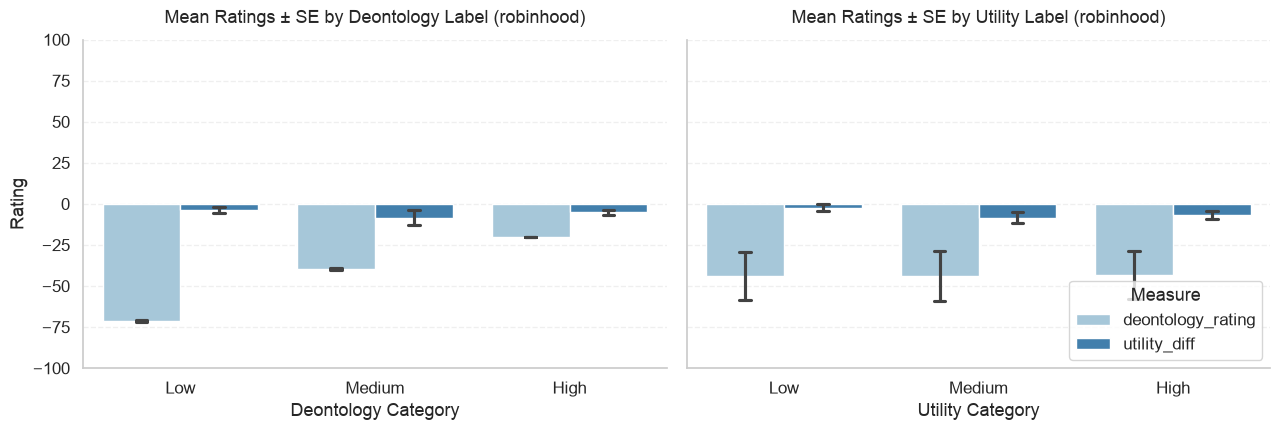

In [20]:
## get plot

# Long format for plotting both dependent measures together
plot_df = results_df.melt(
    id_vars=["deontology_label", "utility_label"],
    value_vars=["deontology_rating", "utility_diff"],
    var_name="measure",
    value_name="value",
)
# Ensure label columns are ordered numerically for plotting
deontology_order = sorted(plot_df["deontology_label"].dropna().astype(int).unique())
utility_order = sorted(plot_df["utility_label"].dropna().astype(int).unique())

plot_df["deontology_label"] = pd.Categorical(
    plot_df["deontology_label"].astype(int),
    categories=deontology_order,
    ordered=True
)
plot_df["utility_label"] = pd.Categorical(
    plot_df["utility_label"].astype(int),
    categories=utility_order,
    ordered=True
)
plot_helper.make_deont_util_plot(NARRATIVE_NAME, plot_df, plots_path)